In [1]:
import os
os.environ["HDF5_USE_FILE_LOCKING"]="FALSE"

In [3]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl

# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.1'):
    raise AssertionError("tutorials rely on cooltools version 0.5.1 or higher,"+
                         "please check your cooltools version and update to the latest")

In [4]:
conditions = [
#     'DE_R1','DE_R2',
    'DE','DEp1','DEp2','DEp3','DEp4','DEp5','DEp6','DEp7','HB',
#     'HB_R1','HB_R2'
]

example = conditions[0]

# note that there is 1 lane of R1 and R2 libraries to reduce size

long_names = {
    'DE_R1': 'DE-FA-DSG-DdeI-DpnII-20220805-lane01__hg38',
    'DE_R2': 'DE-FA-DSG-DdeI-DpnII-20221212-R2-T1-lane01__hg38',
    'DE': 'DE_HiC3_20240517',
    'DEp1': 'DEp1_HiC3_20240517',
    'DEp2': 'DEp2_HiC3_20240517',
    'DEp3': 'DEp3_HiC3_20240517',
    'DEp4': 'DEp4_HiC3_20240517',
    'DEp5': 'DEp5_HiC3_20240517',
    'DEp6': 'DEp6_HiC3_20240517',
    'DEp7': 'DEp7_HiC3_20240517',
    'HB': 'HB_HiC3_20240517',
    'HB_R1': 'HB-FA-DSG-DdeI-DpnII-20220805-lane01__hg38',
    'HB_R2': 'HB-FA-DSG-DdeI-DpnII-20221212-R2-T1-lane01__hg38',
}
    
colors = {
    'DE_R1': '#999999',
    'DE_R2': '#cccccc',
    'DE': '#ffffcc',
    'DEp1': '#ffeda0',
    'DEp2': '#fed976',
    'DEp3': '#feb24c',
    'DEp4': '#fd8d3c',
    'DEp5': '#fc4e2a',
    'DEp6': '#e31a1c',
    'DEp7': '#bd0026',
    'HB': '#800026',
    'HB_R1': '#000000',
    'HB_R2': '#333333',
}


coolerDir = f'/abyss/gibcus/gibcus_mnt_genomics/4DN/coolers'
OutDataDir = f'/abyss/gibcus/gibcus_mnt_genomics/4DN/scaling'
figureDir = f'/sharehome/xiangruhuo/4DN_scripts/plot'

example = conditions[0]
binsize = 1000 

# Load coolers from conditions/Long names
coolersPath = {}
for cond in conditions:
    coolersPath[cond] = '{}/{}.hg38.mapq_30.1000.mcool::resolutions/{}'.format(coolerDir,long_names[cond],binsize)

clrs = {
cond: cooler.Cooler(coolersPath[cond]) for cond in conditions
}

In [5]:
# Use bioframe to fetch the genomic features from the UCSC.
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_chromosomes = list(hg38_chromsizes.index)
hg38_cens = bioframe.fetch_centromeres('hg38')
hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)

# Select only chromosomes that are present in the cooler. 
hg38_arms = hg38_arms.set_index("chrom").loc[clrs[example].chromnames].reset_index()

In [6]:
# cvd == contacts-vs-distance
cvd_smooth_agg = {}

for cond in conditions:
    print("calculating... " +cond)
    cvd_smooth_agg[cond] = cooltools.expected_cis(
        clr=clrs[cond],
        view_df=hg38_arms,
        smooth=True,
        smooth_sigma=0.01,        #control the level of smooting; default is 0.1
        aggregate_smoothed=True,
        nproc=16 #if you do not have multiple cores available, set to 1
    )

INFO:root:creating a Pool of 16 workers


calculating... DE


INFO:root:creating a Pool of 16 workers


calculating... DEp1


INFO:root:creating a Pool of 16 workers


...

calculating... DEp6


INFO:root:creating a Pool of 16 workers


calculating... DEp7


INFO:root:creating a Pool of 16 workers


calculating... HB


In [7]:
for cond in conditions:
    cvd_smooth_agg[cond]['s_bp'] = cvd_smooth_agg[cond]['dist']* binsize
    cvd_smooth_agg[cond]['balanced.avg.smoothed.agg'].loc[cvd_smooth_agg[cond]['dist'] < 2] = np.nan

In [8]:
# Just take a single value for each genomic separation
cvd_merged = {}
for cond in conditions:
    cvd_merged[cond] = cvd_smooth_agg[cond].drop_duplicates(subset=['dist'])[['s_bp', 'balanced.avg.smoothed.agg']]

In [9]:
# Calculate derivative in log-log space
der = {}
for cond in conditions:
    der[cond] = np.gradient(np.log(cvd_merged[cond]['balanced.avg.smoothed.agg']),
                      np.log(cvd_merged[cond]['s_bp']))

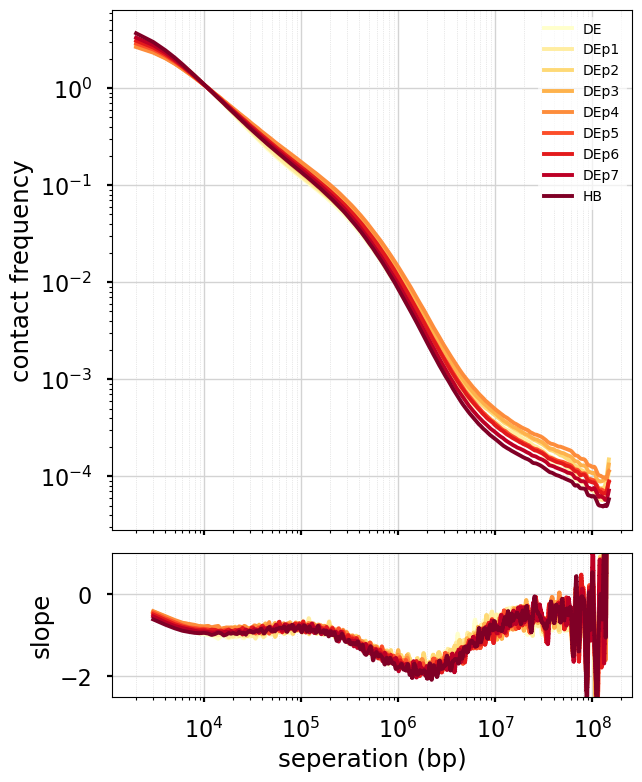

In [10]:
def ScalePlotz():
#     plt.xlim(1e4, 1e6)
#     plt.ylim(1e-2, 1e-1)
    plt.rc('font', weight='normal')
    plt.rc('xtick.major', size=5, pad=7, width=1.5)
    plt.rc('ytick.major', size=5, pad=7, width=1.5)
    plt.rc('xtick.minor', size=3, pad=7, width=1)
    plt.rc('ytick.minor', size=0)
    plt.rc('xtick', labelsize=14)
    plt.rc('ytick', labelsize=14)
    ax.legend(conditions, loc=0, shadow=False, fontsize='medium', frameon=True, facecolor='#FFFFFF', edgecolor='#FFFFFF', framealpha=0.7)
    ax.set_aspect(1.0)
    ax.grid(axis='x', which='minor', color='lightgray', linestyle=':', linewidth=0.5)
    ax.grid(axis='both', which='major', color='lightgray', linestyle='-', linewidth=1)
    ax.set_title('')
    ax.set(
        ylabel='contact frequency',
#         xlim=(1e3,1e8),
#         ylim=(1e-2, 1e-1)
    )
    
def DerivPlotz():
#     plt.xlim(1e3, 1e8)
    plt.ylim(-2.5, 1)
    plt.rc('font', weight='normal')
    plt.rc('xtick.major', size=5, pad=7, width=1.5)
    plt.rc('ytick.major', size=5, pad=7, width=1.5)
    plt.rc('xtick.minor', size=3, pad=7, width=1)
    plt.rc('ytick.minor', size=0)
    plt.rc('xtick', labelsize=14)
    plt.rc('ytick', labelsize=14)
    plt.ylabel("slope")
    plt.xlabel("seperation (bp)")
    ax.grid(axis='x', which='minor', color='lightgray', linestyle=':', linewidth=0.5)
    ax.grid(axis='both', which='major', color='lightgray', linestyle='-', linewidth=1)
    
    
#WT
f, axs = plt.subplots(figsize=(6.5,13),nrows=2,gridspec_kw={'height_ratios':[8,1]},sharex=True)
plt.subplots_adjust(hspace=-0.45,left=0.1)

ax = axs[0]
for cond in conditions:
    ax.loglog(cvd_merged[cond]['s_bp'].values,cvd_merged[cond]['balanced.avg.smoothed.agg'].values/cvd_merged[cond]['balanced.avg.smoothed.agg'][11],'-',markersize=5,color=colors[cond])
ScalePlotz()

ax = axs[1]
for cond in conditions:
    ax.semilogx(cvd_merged[cond]['s_bp'].values,der[cond],alpha=1,color=colors[cond])
DerivPlotz()


from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

pp = PdfPages(f'{figureDir}/{datetime.now().strftime("%Y%m%d-%I%M%S%p")}_H1_scaling.pdf')
plt.savefig(pp, format='pdf')
pp.close()

In [ ]:
#H9

In [12]:
conditions = [
#     'DE_R1','DE_R2',
    'H9-DE','H9-DEp1','H9-DEp2','H9-DEp3','H9-DEp4','H9-DEp5','H9-DEp6','H9-DEp7','H9-HB',
#     'HB_R1','HB_R2'
]

example = conditions[0]

# note that there is 1 lane of R1 and R2 libraries to reduce size

long_names = {
    'H9-DE': 'H9ESCNup155_DE_20241021',
    'H9-DEp1': 'H9ESCNup155_DEp1_20241021',
    'H9-DEp2': 'H9ESCNup155_DEp2_20241021',
    'H9-DEp3': 'H9ESCNup155_DEp3_20241021',
    'H9-DEp4': 'H9ESCNup155_DEp4_20241021',
    'H9-DEp5': 'H9ESCNup155_DEp5_20241021',
    'H9-DEp6': 'H9ESCNup155_DEp6_20241021',
    'H9-DEp7': 'H9ESCNup155_DEp7_20241021',
    'H9-HB': 'H9ESCNup155_HB_20241021',
}

colors = {
    'H9-DE': '#ffffcc',
    'H9-DEp1': '#ffeda0',
    'H9-DEp2': '#fed976',
    'H9-DEp3': '#feb24c',
    'H9-DEp4': '#fd8d3c',
    'H9-DEp5': '#fc4e2a',
    'H9-DEp6': '#e31a1c',
    'H9-DEp7': '#bd0026',
    'H9-HB': '#800026',
}


coolerDir = f'/abyss/gibcus/gibcus_mnt_genomics/4DN/coolers'
OutDataDir = f'/abyss/gibcus/gibcus_mnt_genomics/4DN/scaling'
figureDir = f'/sharehome/xiangruhuo/4DN_scripts/plot'

example = conditions[0]
binsize = 1000 

# Load coolers from conditions/Long names
coolersPath = {}
for cond in conditions:
    coolersPath[cond] = '{}/{}.hg38.mapq_30.1000.mcool::resolutions/{}'.format(coolerDir,long_names[cond],binsize)

clrs = {
cond: cooler.Cooler(coolersPath[cond]) for cond in conditions
}

In [13]:
# Use bioframe to fetch the genomic features from the UCSC.
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_chromosomes = list(hg38_chromsizes.index)
hg38_cens = bioframe.fetch_centromeres('hg38')
hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)

# Select only chromosomes that are present in the cooler. 
hg38_arms = hg38_arms.set_index("chrom").loc[clrs[example].chromnames].reset_index()

In [14]:
# cvd == contacts-vs-distance
cvd_smooth_agg = {}

for cond in conditions:
    print("calculating... " +cond)
    cvd_smooth_agg[cond] = cooltools.expected_cis(
        clr=clrs[cond],
        view_df=hg38_arms,
        smooth=True,
        smooth_sigma=0.01,        #control the level of smooting; default is 0.1
        aggregate_smoothed=True,
        nproc=16 #if you do not have multiple cores available, set to 1
    )

INFO:root:creating a Pool of 16 workers


calculating... H9-DE


INFO:root:creating a Pool of 16 workers


calculating... H9-DEp1


INFO:root:creating a Pool of 16 workers


...

calculating... H9-DEp6


INFO:root:creating a Pool of 16 workers


calculating... H9-DEp7


INFO:root:creating a Pool of 16 workers


calculating... H9-HB


In [15]:
for cond in conditions:
    cvd_smooth_agg[cond]['s_bp'] = cvd_smooth_agg[cond]['dist']* binsize
    cvd_smooth_agg[cond]['balanced.avg.smoothed.agg'].loc[cvd_smooth_agg[cond]['dist'] < 2] = np.nan

In [16]:
# Just take a single value for each genomic separation
cvd_merged = {}
for cond in conditions:
    cvd_merged[cond] = cvd_smooth_agg[cond].drop_duplicates(subset=['dist'])[['s_bp', 'balanced.avg.smoothed.agg']]

In [17]:
# Calculate derivative in log-log space
der = {}
for cond in conditions:
    der[cond] = np.gradient(np.log(cvd_merged[cond]['balanced.avg.smoothed.agg']),
                      np.log(cvd_merged[cond]['s_bp']))

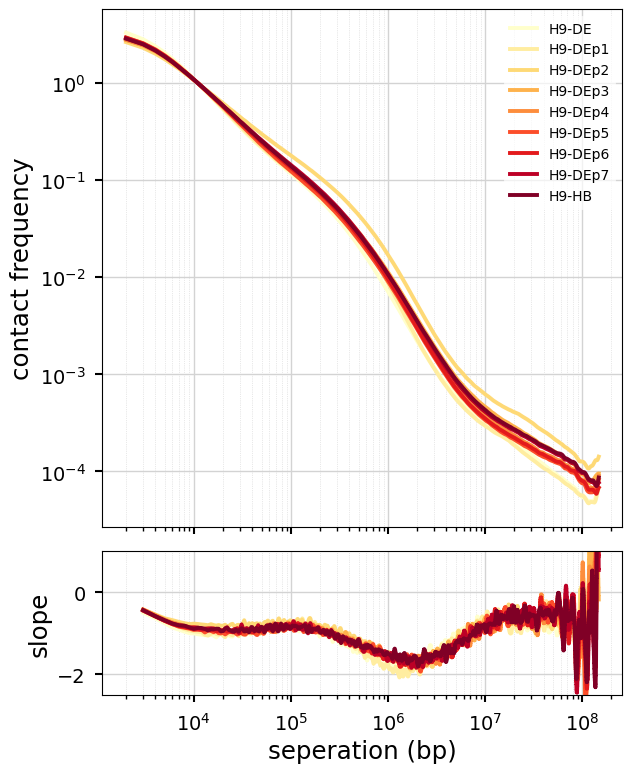

In [18]:
def ScalePlotz():
#     plt.xlim(1e4, 1e6)
#     plt.ylim(1e-2, 1e-1)
    plt.rc('font', weight='normal')
    plt.rc('xtick.major', size=5, pad=7, width=1.5)
    plt.rc('ytick.major', size=5, pad=7, width=1.5)
    plt.rc('xtick.minor', size=3, pad=7, width=1)
    plt.rc('ytick.minor', size=0)
    plt.rc('xtick', labelsize=14)
    plt.rc('ytick', labelsize=14)
    ax.legend(conditions, loc=0, shadow=False, fontsize='medium', frameon=True, facecolor='#FFFFFF', edgecolor='#FFFFFF', framealpha=0.7)
    ax.set_aspect(1.0)
    ax.grid(axis='x', which='minor', color='lightgray', linestyle=':', linewidth=0.5)
    ax.grid(axis='both', which='major', color='lightgray', linestyle='-', linewidth=1)
    ax.set_title('')
    ax.set(
        ylabel='contact frequency',
#         xlim=(1e3,1e8),
#         ylim=(1e-2, 1e-1)
    )

def DerivPlotz():
#     plt.xlim(1e3, 1e8)
    plt.ylim(-2.5, 1)
    plt.rc('font', weight='normal')
    plt.rc('xtick.major', size=5, pad=7, width=1.5)
    plt.rc('ytick.major', size=5, pad=7, width=1.5)
    plt.rc('xtick.minor', size=3, pad=7, width=1)
    plt.rc('ytick.minor', size=0)
    plt.rc('xtick', labelsize=14)
    plt.rc('ytick', labelsize=14)
    plt.ylabel("slope")
    plt.xlabel("seperation (bp)")
    ax.grid(axis='x', which='minor', color='lightgray', linestyle=':', linewidth=0.5)
    ax.grid(axis='both', which='major', color='lightgray', linestyle='-', linewidth=1)
    
    
#WT
f, axs = plt.subplots(figsize=(6.5,13),nrows=2,gridspec_kw={'height_ratios':[8,1]},sharex=True)
plt.subplots_adjust(hspace=-0.45,left=0.1)

ax = axs[0]
for cond in conditions:
    ax.loglog(cvd_merged[cond]['s_bp'].values,cvd_merged[cond]['balanced.avg.smoothed.agg'].values/cvd_merged[cond]['balanced.avg.smoothed.agg'][11],'-',markersize=5,color=colors[cond])
ScalePlotz()

ax = axs[1]
for cond in conditions:
    ax.semilogx(cvd_merged[cond]['s_bp'].values,der[cond],alpha=1,color=colors[cond])
DerivPlotz()


from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

pp = PdfPages(f'{figureDir}/{datetime.now().strftime("%Y%m%d-%I%M%S%p")}_H9_scaling.pdf')
plt.savefig(pp, format='pdf')
pp.close()